# Master fitting file

Change only: 

`MODE`: `fit` or `load`

`CONFIG_FILE`: `fit_{experiments}_{model}.json`

In [1]:
# ============================================================
# Packages
# ============================================================
import sys
import json
import xlrd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import qmc
from model_registry import get_model
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

In [2]:
# ============================================================
# Execution mode
# ============================================================

MODE = "fit"    # run optimization
# MODE = "load" # reuse previous fit

In [3]:
# ============================================================
# Load config
# ============================================================

# Path to the config file defining this run
CONFIG_FILE = "configs/Fig4H_zerofuel/fit_exps12345_model0.json"

# Load JSON config into a Python dictionary
config = json.load(open(CONFIG_FILE))

# Name used to label outputs and saved results
RUN_NAME = config["run_name"]

# Name of the model to use (mapped via model_registry)
MODEL_NAME = config["model_name"]

# Load the selected model module
model = get_model(MODEL_NAME)

# Experimental conditions used for fitting
FIT_CONDITIONS = config["fit_conditions"]

# Full list of all possible experimental conditions
ALL_CONDITIONS = config["all_conditions"]


# # Identify the single condition not used in fitting (held-out)
# HELD_OUT_CONDITION = [c for c in ALL_CONDITIONS if c not in FIT_CONDITIONS][0]

# Identify held-out condition if one exists
held_out_list = [
    c for c in ALL_CONDITIONS
    if c not in FIT_CONDITIONS
]

# Use None when fitting all conditions
HELD_OUT_CONDITION = (
    held_out_list[0]
    if len(held_out_list) > 0
    else None
)

# List of parameters to be optimized
FIT_PARAMS = config["fit_params"]

# Dictionary of all parameters with their central (default) values
ALL_PARAM_INFO = {
    p: {"central": float(v)}
    for p, v in config["all_param_central"].items()
}

# Bounds for fitted parameters in normal (not log) scale
CUSTOM_PARAM_BOUNDS = {
    p: tuple(map(float, bounds))
    for p, bounds in config["custom_param_bounds"].items()
}

# Number of random initial guesses for multi-start fitting
N_STARTS = int(config["n_starts"])

# Random seed for reproducibility
RANDOM_SEED = int(config["random_seed"])

# Path to the Excel file containing experimental data
EXCEL_FILE = config["excel_file"]

# Name of the sheet in the Excel file to read
EXCEL_SHEET = config["excel_sheet"]

# Mapping from condition index to row cutoff for fit/plateau split
row_end_map = config.get("row_end_map", None)

if row_end_map is not None:
    row_end_map = {
        int(k): int(v)
        for k, v in row_end_map.items()
    }

# ============================================================
# Create output folders
# ============================================================

# Directory where results will be saved
RESULTS_DIR = Path(config["results_dir"])
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Directory where figures will be saved
FIGURES_DIR = Path(config["figures_dir"])
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# File path for saving/loading fitted parameters
FIT_RESULTS_FILE = RESULTS_DIR / config["fit_results_file"]

# ============================================================
# Run summary
# ============================================================

print("RUN SUMMARY")
print("="*52)

summary = {
    "Run name": RUN_NAME,
    "Model": MODEL_NAME,
    "Mode": MODE,
    "All conditions": ALL_CONDITIONS,
    "Fit conditions": FIT_CONDITIONS,
    "Held-out": HELD_OUT_CONDITION,
    "Fit parameters": FIT_PARAMS,
    "N starts": N_STARTS,
    "Random seed": RANDOM_SEED,
    "Excel file": EXCEL_FILE,
    "Sheet": EXCEL_SHEET,
    "Results directory": RESULTS_DIR,
    "Figures directory": FIGURES_DIR,
    "Results file": FIT_RESULTS_FILE
}

for k, v in summary.items():
    print(f"{k:<20}: {v}")

RUN SUMMARY
Run name            : fit_exps12345_model0
Model               : model0_transcriptional
Mode                : fit
All conditions      : ['fig4h_0in_0fuel', 'fig4h_1p25in_0fuel', 'fig4h_2p5in_0fuel']
Fit conditions      : ['fig4h_0in_0fuel', 'fig4h_1p25in_0fuel', 'fig4h_2p5in_0fuel']
Held-out            : None
Fit parameters      : ['k_txn', 'ksd', 'kfsd', 'krev', 'kf_rep', 'kRz', 'basal_frac']
N starts            : 50
Random seed         : 1
Excel file          : data/in_vitro_ctRSD_modeling_data.xls
Sheet               : All Data
Results directory   : results/Fig4H_zerofuel
Figures directory   : figures/Fig4H_zerofuel
Results file        : results/Fig4H_zerofuel/fit_exps12345_model0.npz


In [4]:
# ============================================================
# Load experimental data
# ============================================================

# Open the Excel file specified in the config
wb = xlrd.open_workbook(EXCEL_FILE)

# Select the worksheet containing the experimental data
ws = wb.sheet_by_name(EXCEL_SHEET)

# Map condition keys: (column index, input template concentration, fuel template concentration, gate template concentration)
CONDITIONS = {
    # Fig. 2D
    "fig2d_50nM_I0":   (0, 0,    0, 25),
    "fig2d_50nM_I1":   (1, 50,   0, 25),
    "fig2d_25nM_I1":   (2, 25,   0, 25),
    "fig2d_12p5nM_I1": (3, 12.5, 0, 25),
    "fig2d_6p25nM_I1": (4, 6.25, 0, 25),
    "fig2d_2p5nM_I1":  (5, 2.5,  0, 25),

    # Fig. 6C
    "fig6c_10G1_I0":   (6, 0,  0, 10),
    "fig6c_25G1_I0":   (7, 0,  0, 25),
    "fig6c_50G1_I0":   (8, 0,  0, 50),
    "fig6c_10G1_I1":   (9, 50, 0, 10),
    "fig6c_25G1_I1":   (10, 50, 0, 25),
    "fig6c_50G1_I1":   (11, 50, 0, 50),

    # Fig. 4H
    "fig4h_0in_0fuel":      (12, 0,    0, 25),
    "fig4h_1p25in_0fuel":   (13, 1.25, 0, 25),
    "fig4h_2p5in_0fuel":    (14, 2.5,  0, 25),
    "fig4h_0in_25fuel":     (15, 0,    25, 25),
    "fig4h_1p25in_25fuel":  (16, 1.25, 25, 25),
    "fig4h_2p5in_25fuel":   (17, 2.5,  25, 25),
}

# ============================================================
# Data summary
# ============================================================

print("\n" + "="*52)
print("DATA SUMMARY")
print("="*52)

# Print file and sheet being used
print(f"Excel file     : {EXCEL_FILE}")
print(f"Sheet          : {EXCEL_SHEET}")

# Print total number of rows (time points available)
print(f"Total rows     : {ws.nrows}")

# Print condition mapping in readable form
print("\nConditions:")
for k, (col_idx, IN, F, G) in CONDITIONS.items():
    print(f"{k:<22} → col {col_idx}, IN = {IN} nM, Fuel = {F} nM, Gate = {G} nM")

print("="*52 + "\n")


DATA SUMMARY
Excel file     : data/in_vitro_ctRSD_modeling_data.xls
Sheet          : All Data
Total rows     : 2510

Conditions:
fig2d_50nM_I0          → col 0, IN = 0 nM, Fuel = 0 nM, Gate = 25 nM
fig2d_50nM_I1          → col 1, IN = 50 nM, Fuel = 0 nM, Gate = 25 nM
fig2d_25nM_I1          → col 2, IN = 25 nM, Fuel = 0 nM, Gate = 25 nM
fig2d_12p5nM_I1        → col 3, IN = 12.5 nM, Fuel = 0 nM, Gate = 25 nM
fig2d_6p25nM_I1        → col 4, IN = 6.25 nM, Fuel = 0 nM, Gate = 25 nM
fig2d_2p5nM_I1         → col 5, IN = 2.5 nM, Fuel = 0 nM, Gate = 25 nM
fig6c_10G1_I0          → col 6, IN = 0 nM, Fuel = 0 nM, Gate = 10 nM
fig6c_25G1_I0          → col 7, IN = 0 nM, Fuel = 0 nM, Gate = 25 nM
fig6c_50G1_I0          → col 8, IN = 0 nM, Fuel = 0 nM, Gate = 50 nM
fig6c_10G1_I1          → col 9, IN = 50 nM, Fuel = 0 nM, Gate = 10 nM
fig6c_25G1_I1          → col 10, IN = 50 nM, Fuel = 0 nM, Gate = 25 nM
fig6c_50G1_I1          → col 11, IN = 50 nM, Fuel = 0 nM, Gate = 50 nM
fig4h_0in_0fuel        → co

In [5]:
# ============================================================
# Read one experimental trajectory from the Excel worksheet
# ============================================================

def read_condition_column(ws, col_idx, start_row=3):

    # Lists to store experimental time and signal values
    t = []
    x = []

    # Loop through all rows beginning at the first data row
    for r in range(start_row, ws.nrows):

        # Time is always stored in the first column
        time_val = ws.cell_value(r, 0)

        # Experimental signal is stored in the selected condition column
        signal_val = ws.cell_value(r, col_idx + 1)

        # Stop reading when the first blank cell is reached
        # This allows different conditions to have different lengths
        if signal_val == "":
            break

        # Store time and experimental signal
        t.append(time_val)
        x.append(signal_val)

    # Convert lists to numpy arrays
    t = np.array(t)

    # Convert fraction reacted → nM reacted
    x = np.array(x) * 500.0

    # Return the complete experimental trajectory
    return t, x

In [6]:
# ============================================================
# Automatic cutoff function to separate transient and plateau regions
# ============================================================

CUTOFF_FRAC = float(config.get("cutoff_frac", 0.95))
CUTOFF_HOLD_POINTS = int(config.get("cutoff_hold_points", 20))
CUTOFF_DRIFT_TOL = float(config.get("cutoff_drift_tol", 0.03))

def estimate_cutoff_index(t, x, frac=CUTOFF_FRAC, hold_points=CUTOFF_HOLD_POINTS, drift_tol=CUTOFF_DRIFT_TOL):

    # ------------------------------------------------------------
    # Estimate the final plateau level
    # ------------------------------------------------------------

    # Extract the last 10% of the trajectory
    tail = x[int(0.9 * len(x)):]

    # Use the average of the final 10% as the estimated plateau level
    final_level = np.mean(tail)

    # ------------------------------------------------------------
    # Check whether a plateau has actually been reached
    # ------------------------------------------------------------

    # Compute the fractional change across the last 10% of the experiment
    tail_drift = (tail[-1] - tail[0]) / final_level

    # If the final portion is still changing appreciably,
    # assume no plateau was reached during the experiment
    if abs(tail_drift) > drift_tol:
        return len(x)

    # ------------------------------------------------------------
    # Find the end of the transient
    # ------------------------------------------------------------

    # Define the cutoff as a chosen fraction of the estimated plateau
    threshold = frac * final_level

    # Search for the first point that reaches the threshold
    # and remains above it for a fixed number of consecutive samples
    for i in range(len(x) - hold_points):

        if np.all(x[i:i + hold_points] >= threshold):

            # Return local array index, not Excel row number
            return i

    # If no suitable cutoff was found, use the full trajectory
    return len(x)

In [7]:
# ============================================================
# Build dataset
# ============================================================

def build_dataset(cond):

    # Look up column index and concentrations for this condition
    col_idx, IN_conc, Fuel_conc, Gate_conc = CONDITIONS[cond]

    # Read the full trajectory for this condition
    # This allows different condition columns to have different lengths
    t_full, x_full = read_condition_column(ws, col_idx)

    # Use manual cutoff if available
    # Otherwise, estimate cutoff automatically
    if row_end_map is not None and col_idx in row_end_map:
        row_end = row_end_map[col_idx]
    else:
        row_end = estimate_cutoff_index(t_full, x_full)

    # Split full trajectory into fit region
    t = t_full[:row_end]
    x = x_full[:row_end]

    # Split full trajectory into plateau region
    t_plateau = t_full[row_end:]
    x_plateau = x_full[row_end:]

    # Return dataset dictionary containing everything needed later
    return {
        "name": cond,
        "t_exp": t,
        "x_exp": x,
        "t_plateau": t_plateau,
        "x_plateau": x_plateau,
        "IN_conc": IN_conc,
        "Fuel_conc": Fuel_conc,
        "RSD_temp": Gate_conc
    }


# Build datasets used for fitting
datasets = [build_dataset(c) for c in FIT_CONDITIONS]

# # Build dataset used for held-out prediction
# HELD_OUT_DATASET = build_dataset(HELD_OUT_CONDITION)
# Build dataset used for held-out prediction, if one exists
if HELD_OUT_CONDITION is not None:
    HELD_OUT_DATASET = build_dataset(HELD_OUT_CONDITION)
else:
    HELD_OUT_DATASET = None

# ============================================================
# Dataset summary
# ============================================================

print("="*52)
print("DATASET SUMMARY")
print("="*52)

print("\nFitted datasets:")
for d in datasets:
    print(
        f"{d['name']:<18} | "
        f"fit points = {len(d['t_exp']):<4} | "
        f"excluded points = {len(d['x_plateau']):<4} | "
        f"IN = {d['IN_conc']} nM | "
        f"Fuel = {d['Fuel_conc']} nM "
    )

if HELD_OUT_DATASET is not None:
    d = HELD_OUT_DATASET
    print("\nHeld-out dataset:")
    print(
        f"{d['name']:<18} | "
        f"fit points = {len(d['t_exp']):<4} | "
        f"excluded points = {len(d['x_plateau']):<4} | "
        f"IN = {d['IN_conc']} nM | "
        f"Fuel = {d['Fuel_conc']} nM "
    )
else:
    print("\nHeld-out dataset: None")

DATASET SUMMARY

Fitted datasets:
fig4h_0in_0fuel    | fit points = 1673 | excluded points = 834  | IN = 0 nM | Fuel = 0 nM 
fig4h_1p25in_0fuel | fit points = 1042 | excluded points = 1465 | IN = 1.25 nM | Fuel = 0 nM 
fig4h_2p5in_0fuel  | fit points = 454  | excluded points = 2053 | IN = 2.5 nM | Fuel = 0 nM 

Held-out dataset: None


Saved figure → figures/Fig4H_zerofuel/fit_exps12345_model0_experimentaldata.png


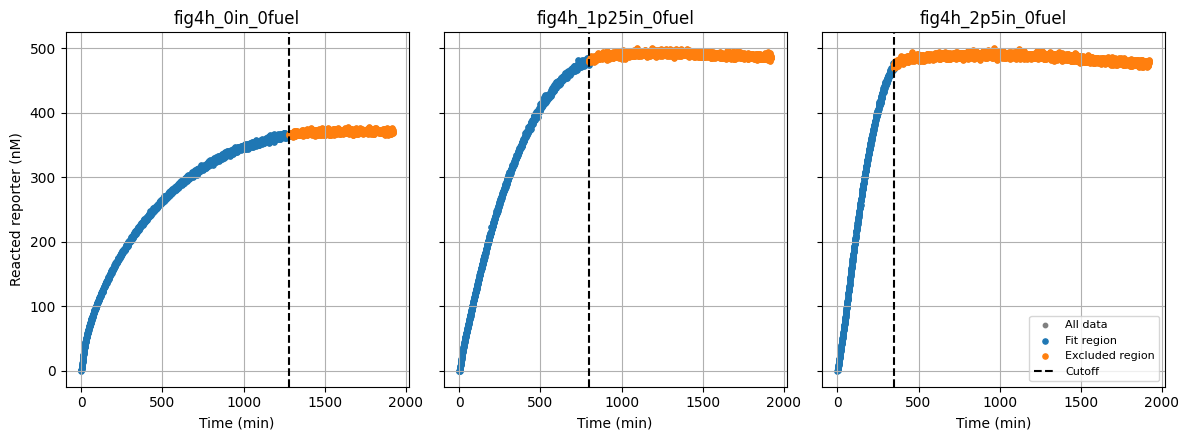

In [8]:
# ============================================================
# Visual check: transient fitting region
# ============================================================

# Maximum number of panels per row
max_cols = 6

# Number of fitted datasets
n = len(datasets)

# Number of columns
ncols = min(n, max_cols)

# Number of rows
nrows = int(np.ceil(n / max_cols))

# Create subplot grid
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(4 * ncols, 4.5 * nrows),
    sharey=True
)

# Flatten axes for easy looping
axes = np.array(axes).reshape(-1)

# Loop over fitted datasets
for ax, d in zip(axes, datasets):

    # Reconstruct full experimental trajectory
    t_full = np.concatenate([d["t_exp"], d["t_plateau"]])
    x_full = np.concatenate([d["x_exp"], d["x_plateau"]])

    # Plot full experimental trajectory
    ax.scatter(
        t_full,
        x_full,
        s=10,
        color="gray",
        label="All data"
    )

    # Highlight transient region used for fitting
    ax.scatter(
        d["t_exp"],
        d["x_exp"],
        s=14,
        label="Fit region"
    )

    # Highlight excluded late-time region
    if len(d["t_plateau"]) > 0:
        ax.scatter(
            d["t_plateau"],
            d["x_plateau"],
            s=14,
            label="Excluded region"
        )

    # Draw transient cutoff
    ax.axvline(
        d["t_exp"][-1],
        linestyle="--",
        linewidth=1.5,
        color="black",
        label="Cutoff"
    )

    # Add condition title
    ax.set_title(d["name"])

    # Label x-axis
    ax.set_xlabel("Time (min)")

    # Show grid
    ax.grid(True)

# Hide unused axes
for ax in axes[len(datasets):]:
    ax.axis("off")

# Label shared y-axis
axes[0].set_ylabel("Reacted reporter (nM)")

# Show legend once
axes[len(datasets) - 1].legend(fontsize=8)

# Adjust layout
plt.tight_layout()

# Save figure
fig.savefig(
    FIGURES_DIR / f"{RUN_NAME}_experimentaldata.png",
    dpi=300,
    bbox_inches="tight"
)

# Confirm save
print(f"Saved figure → {FIGURES_DIR / f'{RUN_NAME}_experimentaldata.png'}")

# Display figure
plt.show()

In [9]:
# ============================================================
# Prediction function
# ============================================================

def predict(d, params):

    # Experimental times are stored in minutes
    t_eval_min = d["t_exp"]

    # Model rates are in seconds, so convert minutes → seconds
    t_eval_sec = np.asarray(t_eval_min, dtype=float) * 60.0

    # Simulate the model timecourse
    sol = solve_ivp(
        lambda t, y: model.rhs(
            t, y,
            RSD_temp=d["RSD_temp"],
            IN_temp=d["IN_conc"],
            F_temp=d["Fuel_conc"],
            params=params
        ),
        (t_eval_sec[0], t_eval_sec[-1]),
        model.initial_conditions(d, params),
        t_eval=t_eval_sec,
        method="LSODA",
        rtol=1e-6,
        atol=1e-6
    )

    # If solver failed, return a large penalty trajectory
    if (not sol.success) or np.any(~np.isfinite(sol.y)):
        return np.full_like(t_eval_min, 1e9, dtype=float)

    # If solver output shape is wrong, return a large penalty trajectory
    if sol.y.shape[0] <= model.output_index:
        return np.full_like(t_eval_min, 1e9, dtype=float)

    # Extract the model output, usually ROL
    return sol.y[model.output_index]

In [10]:
# ============================================================
# Normalized residual for one dataset
# ============================================================

def compute_normalized_residual(d, params):

    # Generate model prediction
    x_model = predict(d, params)

    # Raw residual = model - experiment
    res = x_model - d["x_exp"]

    # Vertical normalization factor
    # Prevent datasets with larger signal amplitudes from dominating
    scale = np.max(d["x_exp"]) if np.max(d["x_exp"]) > 0 else 1.0

    # Horizontal normalization factor
    # Prevent datasets with more time points from dominating
    points = len(d["x_exp"])

    # Return normalized residual
    return res / scale / np.sqrt(points)

In [11]:
# ============================================================
# Residual function used by least_squares
# ============================================================

def residuals(log_params):

    # Start with all parameters set to their central/default values
    params = {p: ALL_PARAM_INFO[p]["central"] for p in ALL_PARAM_INFO}

    # Overwrite fitted parameters using current log10 values
    for i, p in enumerate(FIT_PARAMS):

        # Convert log10 parameter → normal scale
        params[p] = 10**log_params[i]

    # Return one concatenated residual vector across fitted datasets
    return np.concatenate([
        compute_normalized_residual(d, params)
        for d in datasets
    ])

In [12]:
# ============================================================
# Fit or load parameters
# ============================================================

# Lower bounds for parameters in log10 space
lower_bounds = np.array([
    np.log10(CUSTOM_PARAM_BOUNDS[p][0])
    for p in FIT_PARAMS
])

# Upper bounds for parameters in log10 space
upper_bounds = np.array([
    np.log10(CUSTOM_PARAM_BOUNDS[p][1])
    for p in FIT_PARAMS
])

# If mode is "fit", run optimization
if MODE == "fit":

    # --------------------------------------------------------
    # Generate Sobol initial guesses in log10 parameter space
    # --------------------------------------------------------

    # Requested number of optimization starts
    N_STARTS_REQUESTED = N_STARTS

    # Sobol sequences are best generated using powers of two
    m = int(np.ceil(np.log2(N_STARTS_REQUESTED)))
    N_STARTS = 2**m

    print(
        f"\nRequested {N_STARTS_REQUESTED} optimization starts."
        f"\nUsing {N_STARTS} Sobol starts (next power of two).\n"
    )

    sampler = qmc.Sobol(
        d=len(FIT_PARAMS),
        scramble=True,
        seed=RANDOM_SEED
    )

    # Sobol points in the unit hypercube [0,1]^d
    U = sampler.random_base2(m=m)

    # Transform Sobol points into log10 parameter space
    x0_all = lower_bounds + U * (upper_bounds - lower_bounds)


    # --------------------------------------------------------
    # Multi-start optimization
    # --------------------------------------------------------

    # Dummy variable to store best result across all Sobol starts
    best = None

    # Loop over each Sobol initial guess
    for i, x0 in enumerate(x0_all):

        # Run least-squares optimization from this starting point
        result = least_squares(
            residuals,
            x0,
            bounds=(lower_bounds, upper_bounds)
        )

        # Print progress
        print(f"Run {i+1}/{N_STARTS} | cost = {result.cost:.4e}")

        # If this run is the best so far, update dummy above
        if best is None or result.cost < best.cost:
            best = result

    # Extract best-fit log10 parameter values
    best_x = best.x

    # Extract corresponding optimization cost
    best_cost = best.cost

    # Save best fit results to .npz file
    np.savez(
        FIT_RESULTS_FILE,
        best_x=best_x,
        best_cost=best_cost,
        fit_params=np.array(FIT_PARAMS, dtype=object)
    )

    # Confirm save
    print(f"\nSaved fit results → {FIT_RESULTS_FILE}")

# If mode is "load", load previous fit results
elif MODE == "load":

    # Load best-fit log10 parameters and cost from .npz file
    data = np.load(FIT_RESULTS_FILE, allow_pickle=True)
    best_x = data["best_x"]
    best_cost = float(data["best_cost"])

    print(f"\nLoaded fit results → {FIT_RESULTS_FILE}")


# Convert best log10 parameters to linear scale and map to parameter names
# Start with all parameters fixed at their central/default values
best_fit_params = {
    p: ALL_PARAM_INFO[p]["central"]
    for p in ALL_PARAM_INFO}
# Overwrite only the parameters that were fitted
for i, p in enumerate(FIT_PARAMS):
    best_fit_params[p] = 10**best_x[i]


# Convert cost to SSE (since cost = 0.5 * SSE)
best_sse = 2 * best_cost

# Print summary
print("\nBest-fit parameters:")
for p, v in best_fit_params.items():
    print(f"{p:<15} = {v:.4e}")

print(f"\nBest cost (0.5 * SSE) = {best_cost:.4e}")
print(f"Best SSE (normalized) = {best_sse:.4e}")


Requested 50 optimization starts.
Using 64 Sobol starts (next power of two).

Run 1/64 | cost = 1.8939e-02
Run 2/64 | cost = 2.9671e-01
Run 3/64 | cost = 4.4533e-01
Run 4/64 | cost = 1.9690e-02
Run 5/64 | cost = 2.1454e-02
Run 6/64 | cost = 3.0154e-01
Run 7/64 | cost = 4.1439e-01
Run 8/64 | cost = 2.9454e-01
Run 9/64 | cost = 8.7455e-02
Run 10/64 | cost = 2.1060e-02
Run 11/64 | cost = 1.3308e-01
Run 12/64 | cost = 3.0036e-01
Run 13/64 | cost = 1.9490e-02
Run 14/64 | cost = 3.3996e-02
Run 15/64 | cost = 1.9951e-02
Run 16/64 | cost = 2.2360e-02
Run 17/64 | cost = 2.9411e-01
Run 18/64 | cost = 3.6729e-02
Run 19/64 | cost = 2.9691e-01
Run 20/64 | cost = 2.8132e-02
Run 21/64 | cost = 2.9508e-01
Run 22/64 | cost = 3.0707e-02
Run 23/64 | cost = 3.0218e-01
Run 24/64 | cost = 1.9032e-02
Run 25/64 | cost = 2.9401e-01
Run 26/64 | cost = 2.1397e-02
Run 27/64 | cost = 2.9748e-01
Run 28/64 | cost = 4.2567e-01
Run 29/64 | cost = 6.5532e-01
Run 30/64 | cost = 3.3840e-02
Run 31/64 | cost = 3.2011e-02


Saved figure → figures/Fig4H_zerofuel/fit_exps12345_model0_sobolsamples.png


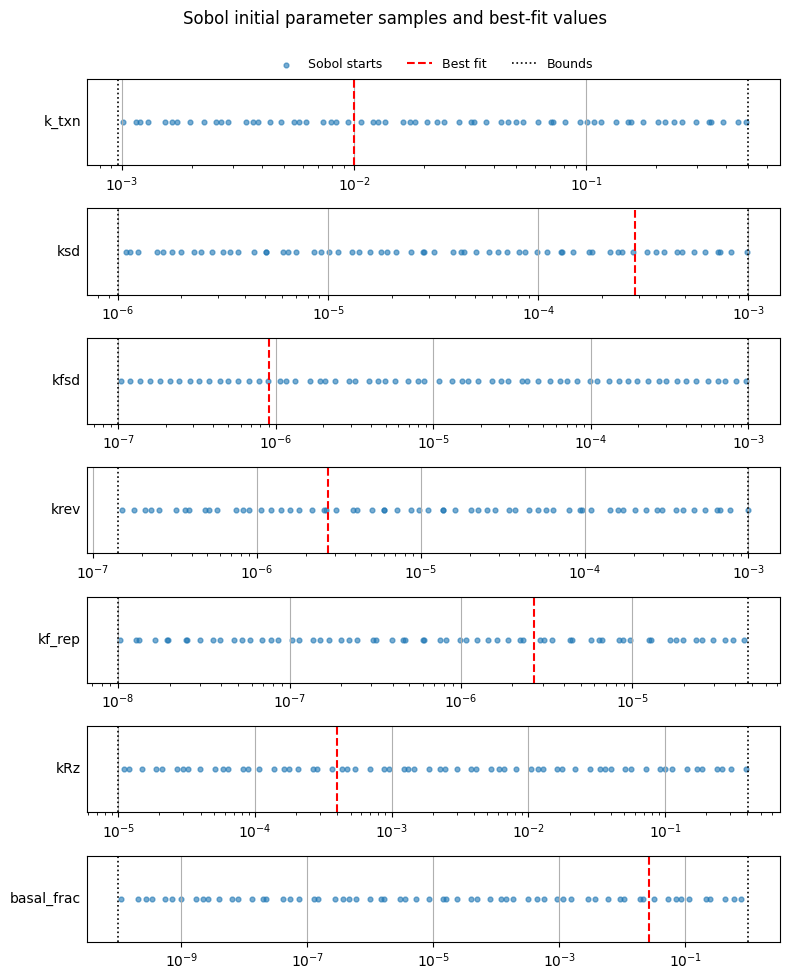

In [13]:
# ============================================================
# Plot Sobol sampled initial parameter points
# ============================================================

# Only plot initial samples if a fitting run was performed
if MODE == "fit":

    # Convert Sobol samples from log10 space back to parameter values
    x0_all_linear = 10**x0_all

    # Create one horizontal number line for each fitted parameter
    fig, axes = plt.subplots(
        len(FIT_PARAMS),
        1,
        figsize=(8, 1.4 * len(FIT_PARAMS)),
        sharex=False
    )

    # Flatten axes for easy looping
    axes = np.array(axes).reshape(-1)

    # ------------------------------------------------------------
    # Plot sampled values for each fitted parameter
    # ------------------------------------------------------------

    for i, p in enumerate(FIT_PARAMS):

        ax = axes[i]

        # Parameter bounds
        lower, upper = CUSTOM_PARAM_BOUNDS[p]

        # Plot Sobol initial guesses
        ax.scatter(
            x0_all_linear[:, i],
            np.zeros(len(x0_all_linear)),
            s=12,
            alpha=0.6,
            label="Sobol starts" if i == 0 else None
        )

        # Plot best-fit parameter value
        ax.axvline(
            best_fit_params[p],
            linestyle="--",
            linewidth=1.5,
            color="red",
            label="Best fit" if i == 0 else None
        )

        # Plot lower parameter bound
        ax.axvline(
            lower,
            linestyle=":",
            linewidth=1.2,
            color="black",
            label="Bounds" if i == 0 else None
        )

        # Plot upper parameter bound
        ax.axvline(
            upper,
            linestyle=":",
            linewidth=1.2,
            color="black"
        )

        # Display parameter values on a logarithmic scale
        ax.set_xscale("log")

        # Remove y-axis ticks (only horizontal position is meaningful)
        ax.set_yticks([])

        # Label each parameter
        ax.set_ylabel(
            p,
            rotation=0,
            ha="right",
            va="center"
        )

        # Show vertical grid lines
        ax.grid(True, axis="x")

    # ------------------------------------------------------------
    # Figure formatting
    # ------------------------------------------------------------

    # Add figure title
    fig.suptitle(
        "Sobol initial parameter samples and best-fit values",
        y=0.995
    )

    # Show legend once above the first subplot
    axes[0].legend(
        loc="lower center",
        bbox_to_anchor=(0.5, 0.965),
        ncol=3,
        frameon=False,
        fontsize=9
    )

    # Adjust subplot spacing
    plt.tight_layout(rect=[0, 0, 1, 1])

    # ------------------------------------------------------------
    # Save + show
    # ------------------------------------------------------------

    fig.savefig(
        FIGURES_DIR / f"{RUN_NAME}_sobolsamples.png",
        dpi=300,
        bbox_inches="tight"
    )

    print(f"Saved figure → {FIGURES_DIR / f'{RUN_NAME}_sobolsamples.png'}")
    plt.show()

else:

    print("\nSobol initial sample plot skipped because MODE = 'load'.")

In [14]:
# ============================================================
# Compute RMSE (fit + held-out datasets)
# ============================================================

# Function to compute Root Mean Squared Error for one dataset
def compute_rmse(d, params):

    # Generate model prediction for this dataset
    x_model = predict(d, params)

    # Compute RMSE between model and experimental data
    # RMSE = sqrt(mean((model - data)^2))
    return np.sqrt(np.mean((x_model - d["x_exp"])**2))


# ------------------------------------------------------------
# RMSE for fitted datasets
# ------------------------------------------------------------

print("\nRMSE (fit datasets):")

# Loop through all datasets used in fitting
for d in datasets:

    # Print dataset name and its RMSE
    print(d["name"], compute_rmse(d, best_fit_params))


# ------------------------------------------------------------
# RMSE for held-out dataset (not used in fitting)
# ------------------------------------------------------------

print("\nRMSE (held-out):")

# Only evaluate held-out prediction if a held-out dataset exists
if HELD_OUT_DATASET is not None:
    print(
        HELD_OUT_DATASET["name"],
        compute_rmse(HELD_OUT_DATASET, best_fit_params)
    )
else:
    print("None")


RMSE (fit datasets):
fig4h_0in_0fuel 64.15452181323083
fig4h_1p25in_0fuel 37.14968452967488
fig4h_2p5in_0fuel 20.009751021968437

RMSE (held-out):
None


In [15]:
# ============================================================
# Compute global RMSE
# ============================================================

def compute_global_rmse(dataset_list, params):

    # Use the same normalized residual definition as fitting
    all_residuals = np.concatenate([
        compute_normalized_residual(d, params)
        for d in dataset_list
    ])

    # Compute RMSE over all normalized residuals
    return np.sqrt(np.mean(all_residuals**2))

In [16]:
# ------------------------------------------------------------
# Global RMSE (fit datasets)
# ------------------------------------------------------------

global_fit_rmse = compute_global_rmse(datasets, best_fit_params)

print("\nGlobal RMSE (fit datasets):")
print(global_fit_rmse)


# ------------------------------------------------------------
# Global RMSE (fit + held-out)
# ------------------------------------------------------------

# Include held-out dataset only if one exists
if HELD_OUT_DATASET is not None:
    datasets_all = datasets + [HELD_OUT_DATASET]
else:
    datasets_all = datasets

# Compute overall RMSE
global_all_rmse = compute_global_rmse(
    datasets_all,
    best_fit_params
)

print("\nGlobal RMSE (all datasets):")
print(global_all_rmse)


Global RMSE (fit datasets):
0.00345727138063841

Global RMSE (all datasets):
0.00345727138063841


Saved figure → figures/Fig4H_zerofuel/fit_exps12345_model0_fit_timecourses.png


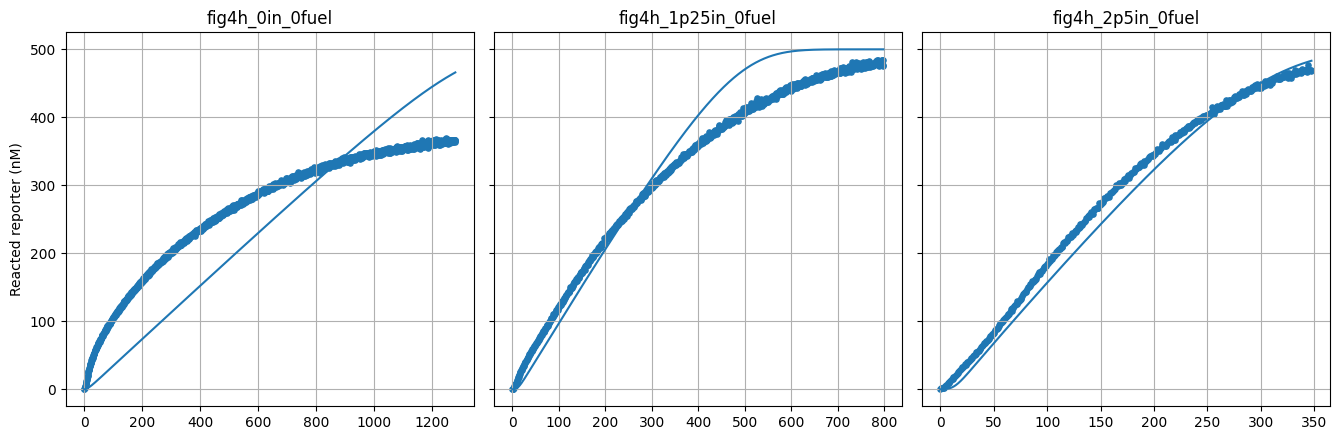

In [17]:
# ============================================================
# Plot fitted datasets (model vs experiment)
# ============================================================

# Maximum number of panels per row
max_cols = 6

# Number of fitted datasets
n = len(datasets)

# Number of columns is either n or max_cols, whichever is smaller
ncols = min(n, max_cols)

# Number of rows needed to fit all datasets
nrows = int(np.ceil(n / max_cols))

# Create subplot grid
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(4.5 * ncols, 4.5 * nrows),
    sharey=True
)

# Make axes a flat list so looping works for any grid shape
axes = np.array(axes).reshape(-1)

# ------------------------------------------------------------
# Plot each dataset
# ------------------------------------------------------------
for ax, d in zip(axes, datasets):

    # Generate model prediction for this dataset
    x_model = predict(d, best_fit_params)

    # Plot model prediction (line)
    ax.plot(d["t_exp"], x_model)

    # Plot experimental data (points)
    ax.scatter(d["t_exp"], d["x_exp"], s=14)

    # Title = condition name
    ax.set_title(d["name"])

    # Enable grid for readability
    ax.grid(True)

# Hide unused axes
for ax in axes[len(datasets):]:
    ax.axis("off")
    
# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

# Label y-axis only once (shared across all panels)
axes[0].set_ylabel("Reacted reporter (nM)")

# Adjust layout to prevent overlap
plt.tight_layout()

# ------------------------------------------------------------
# Save + show
# ------------------------------------------------------------

fig.savefig(
    FIGURES_DIR / f"{RUN_NAME}_fit_timecourses.png",
    dpi=300,
    bbox_inches="tight"
)

print(f"Saved figure → {FIGURES_DIR / f'{RUN_NAME}_fit_timecourses.png'}")
plt.show()

In [18]:
# ============================================================
# Plot held-out dataset (prediction vs experiment)
# ============================================================

# Only generate held-out prediction plot if a held-out dataset exists
if HELD_OUT_DATASET is not None:

    # Select the dataset that was NOT used during fitting
    d = HELD_OUT_DATASET

    # Generate model prediction using fitted parameters
    x_pred = predict(d, best_fit_params)

    # Create a new figure
    plt.figure(figsize=(5, 4))


    # ------------------------------------------------------------
    # Plot model prediction
    # ------------------------------------------------------------

    # Dashed red line = model prediction (not fitted to this data)
    plt.plot(
        d["t_exp"],
        x_pred,
        "--",
        color="red",
        label="Prediction"
    )


    # ------------------------------------------------------------
    # Plot experimental data
    # ------------------------------------------------------------

    # Scatter points = actual experimental measurements
    plt.scatter(
        d["t_exp"],
        d["x_exp"],
        s=14,
        label="Experiment"
    )


    # ------------------------------------------------------------
    # Formatting
    # ------------------------------------------------------------

    # Title indicates this dataset was held-out during fitting
    plt.title(f"{d['name']} (held-out)")

    # Add legend to distinguish prediction vs data
    plt.legend()

    # Grid for readability
    plt.grid(True)

    # ------------------------------------------------------------
    # Save + show
    # ------------------------------------------------------------

    # Save figure before showing
    plt.savefig(
        FIGURES_DIR / f"{RUN_NAME}_heldout_prediction.png",
        dpi=300,
        bbox_inches="tight"
    )
    
    print(f"Saved figure → {FIGURES_DIR / f'{RUN_NAME}_heldout_prediction.png'}")
    plt.show()

else:
    print("\nNo held-out dataset to plot.")


No held-out dataset to plot.


Saved figure → figures/Fig4H_zerofuel/fit_exps12345_model0_cost_landscapes.png


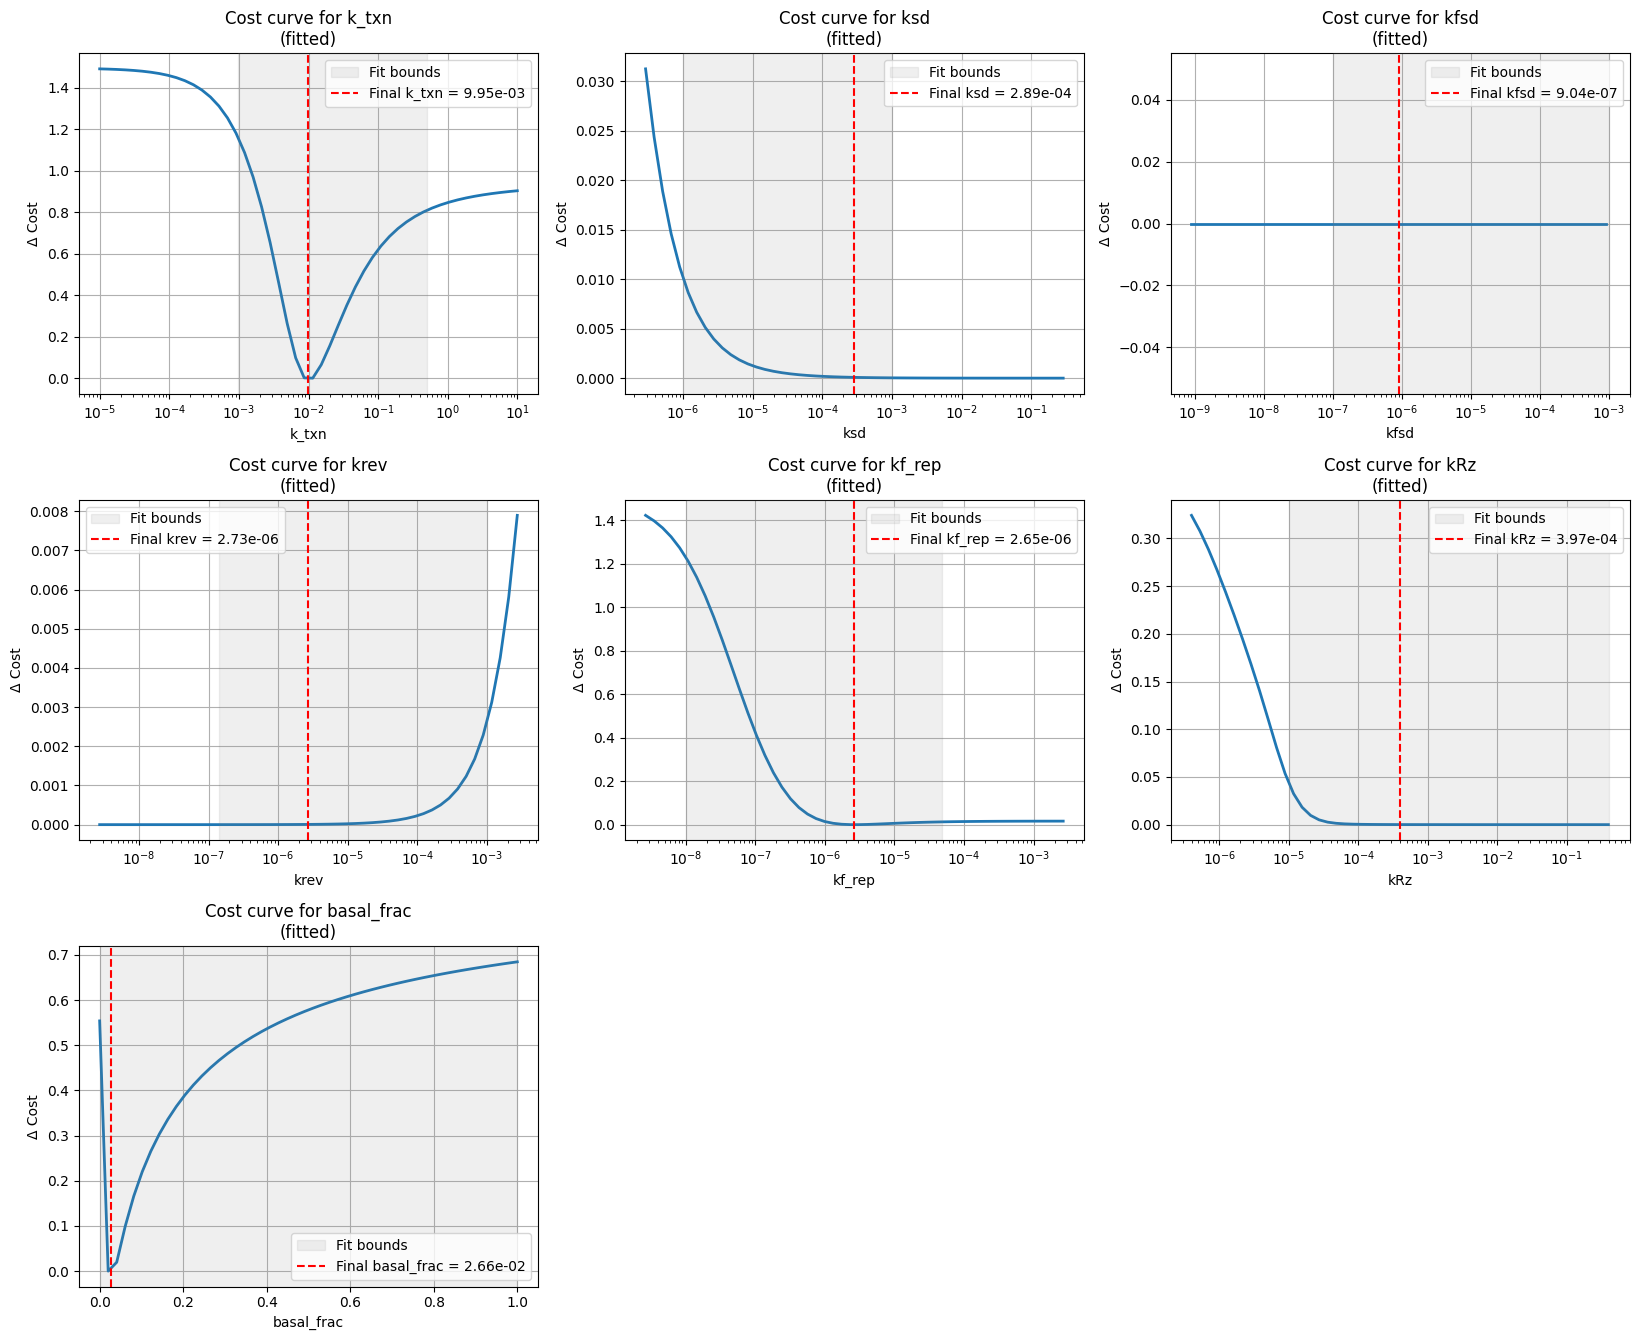

In [19]:
# ============================================================
# Cost landscapes for fitted parameters
#
# Purpose:
# Plot one-parameter cost landscapes by varying each fitted
# parameter around its best-fit value while keeping all other
# parameters fixed.
# ============================================================

# Parameters to scan
SCAN_PARAMS = FIT_PARAMS.copy()

# Default scan width for log-scale parameters
# Example: 2.0 means 2 orders below and 2 orders above best fit
SCAN_HALF_WIDTH_LOG10 = 3.0

# Default number of scan points
N_SCAN = 50

# OPTIONAL:
# Parameters to scan and plot on a linear x-axis
# Key = parameter name, value = manual linear scan range
LINEAR_SCAN_RANGES = {
    "misfold_frac": (0, 1),
    "basal_frac": (0, 1)
}

# Maximum number of parameter plots per row
max_cols = 3

# Number of parameters being scanned
n_params = len(SCAN_PARAMS)

# Number of columns and rows
ncols = min(max_cols, n_params)
nrows = int(np.ceil(n_params / max_cols))

# Create subplot grid
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5.5 * ncols, 4.5 * nrows)
)

# Flatten axes for easy looping
axes = np.array(axes).reshape(-1)


# ------------------------------------------------------------
# Loop through each scanned parameter
# ------------------------------------------------------------

for ax, p in zip(axes, SCAN_PARAMS):

    # Best-fit value for this parameter
    center_val = best_fit_params[p]
    center_log10 = np.log10(center_val)

    # --------------------------------------------------------
    # Generate scan values
    # --------------------------------------------------------

    if p in LINEAR_SCAN_RANGES:

        # Use user-defined linear range if available
        if p in LINEAR_SCAN_RANGES:
            scan_lower, scan_upper = LINEAR_SCAN_RANGES[p]

        # Otherwise use fitted parameter bounds
        elif p in CUSTOM_PARAM_BOUNDS:
            scan_lower, scan_upper = CUSTOM_PARAM_BOUNDS[p]
        
        # Generate linearly spaced parameter values
        param_vals = np.linspace(scan_lower, scan_upper, N_SCAN)

    else:

        # Default: scan in log space around best-fit value
        scan_lower_log10 = center_log10 - SCAN_HALF_WIDTH_LOG10
        scan_upper_log10 = center_log10 + SCAN_HALF_WIDTH_LOG10

        # Generate logarithmically spaced parameter values
        param_vals = np.logspace(
            scan_lower_log10,
            scan_upper_log10,
            N_SCAN
        )

    # List to store cost values for this parameter
    cost_vals = []

    # --------------------------------------------------------
    # Evaluate cost across parameter values
    # --------------------------------------------------------

    for p_test in param_vals:

        # Copy best-fit parameters
        params = best_fit_params.copy()

        # Replace only the scanned parameter
        params[p] = p_test

        try:

            # Compute normalized residuals across fitted datasets
            res_all = np.concatenate([
                compute_normalized_residual(d, params)
                for d in datasets
            ])

            # Cost = sum of squared normalized residuals
            cost = np.sum(res_all**2)

            # Use NaN for invalid simulations
            if not np.isfinite(cost):
                cost = np.nan

        except Exception:

            # Use NaN if the solver fails
            cost = np.nan

        # Store cost value
        cost_vals.append(cost)

    # Convert cost list to numpy array
    cost_vals = np.array(cost_vals, dtype=float)

    # Compute change in cost relative to minimum finite value
    delta_cost = cost_vals - np.nanmin(cost_vals)

    # --------------------------------------------------------
    # Plot cost landscape
    # --------------------------------------------------------

    if p in LINEAR_SCAN_RANGES:

        # Linear x-axis for selected parameters
        ax.plot(
            param_vals,
            delta_cost,
            linewidth=2
        )

    else:

        # Log x-axis for default parameters
        ax.semilogx(
            param_vals,
            delta_cost,
            linewidth=2
        )

    # Plot fitted parameter bounds as shaded region
    if p in CUSTOM_PARAM_BOUNDS:

        lower_bound, upper_bound = CUSTOM_PARAM_BOUNDS[p]

        ax.axvspan(
            lower_bound,
            upper_bound,
            alpha=0.12,
            color="gray",
            label="Fit bounds",
            zorder=3
        )

    # Plot best-fit parameter value
    ax.axvline(
        best_fit_params[p],
        linestyle="--",
        linewidth=1.5,
        color="red",
        label=f"Final {p} = {best_fit_params[p]:.2e}",
        zorder=4
    )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.set_xlabel(p)
    ax.set_ylabel("Δ Cost")
    ax.set_title(f"Cost curve for {p}\n(fitted)")
    ax.grid(True)
    ax.legend()


# Hide unused axes
for ax in axes[n_params:]:
    ax.axis("off")

plt.tight_layout()


# ------------------------------------------------------------
# Save + show
# ------------------------------------------------------------

fig.savefig(
    FIGURES_DIR / f"{RUN_NAME}_cost_landscapes.png",
    dpi=300,
    bbox_inches="tight"
)

print(f"Saved figure → {FIGURES_DIR / f'{RUN_NAME}_cost_landscapes.png'}")
plt.show()

In [20]:
# ============================================================
# Check whether fitted parameters are close to bounds
# ============================================================

print("\nBoundary proximity check:")
print("-" * 52)

# Parameters whose boundary proximity should be measured
# on a linear scale rather than a log scale
LINEAR_BOUNDARY_PARAMS = [
    "basal_frac",
    "misfold_frac"
]

# Fraction of the search range considered "near" a bound
BOUNDARY_TOL = 0.05

# Store boundary information for later reporting
boundary_check = []

# ------------------------------------------------------------
# Loop through each fitted parameter
# ------------------------------------------------------------

for i, p in enumerate(FIT_PARAMS):

    # --------------------------------------------------------
    # Compute normalized distance to each bound
    # --------------------------------------------------------

    if p in LINEAR_BOUNDARY_PARAMS:

        # Use linear distance for fraction-type parameters
        value = best_fit_params[p]
        lower = CUSTOM_PARAM_BOUNDS[p][0]
        upper = CUSTOM_PARAM_BOUNDS[p][1]

        parameter_range = upper - lower

        dist_to_lower = (value - lower) / parameter_range
        dist_to_upper = (upper - value) / parameter_range

    else:

        # Default: compute distances in log10 space
        log_val = best_x[i]
        log_lower = lower_bounds[i]
        log_upper = upper_bounds[i]

        parameter_range = log_upper - log_lower

        dist_to_lower = (log_val - log_lower) / parameter_range
        dist_to_upper = (log_upper - log_val) / parameter_range

        # Convert back to linear values for reporting
        value = 10**log_val
        lower = 10**log_lower
        upper = 10**log_upper

    # --------------------------------------------------------
    # Determine boundary status
    # --------------------------------------------------------

    if dist_to_lower < BOUNDARY_TOL:
        status = "near lower bound"

    elif dist_to_upper < BOUNDARY_TOL:
        status = "near upper bound"

    else:
        status = "not within 5% of bound"

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    boundary_check.append({
        "parameter": p,
        "value": value,
        "lower": lower,
        "upper": upper,
        "dist_to_lower": dist_to_lower,
        "dist_to_upper": dist_to_upper,
        "status": status
    })

    # --------------------------------------------------------
    # Print summary
    # --------------------------------------------------------

    print(
        f"{p:<15} | "
        f"value = {value:.4e} | "
        f"lower = {lower:.4e} | "
        f"upper = {upper:.4e} | "
        f"{status}"
    )


Boundary proximity check:
----------------------------------------------------
k_txn           | value = 9.9497e-03 | lower = 9.6276e-04 | upper = 5.0000e-01 | not within 5% of bound
ksd             | value = 2.8907e-04 | lower = 1.0000e-06 | upper = 1.0000e-03 | not within 5% of bound
kfsd            | value = 9.0354e-07 | lower = 1.0000e-07 | upper = 1.0000e-03 | not within 5% of bound
krev            | value = 2.7300e-06 | lower = 1.4271e-07 | upper = 1.0000e-03 | not within 5% of bound
kf_rep          | value = 2.6542e-06 | lower = 1.0000e-08 | upper = 4.7712e-05 | not within 5% of bound
kRz             | value = 3.9683e-04 | lower = 1.0000e-05 | upper = 4.0680e-01 | not within 5% of bound
basal_frac      | value = 2.6644e-02 | lower = 1.0000e-10 | upper = 1.0000e+00 | near lower bound


In [21]:
# ------------------------------------------------------------
# Save run summary to text file
# ------------------------------------------------------------

summary_file = RESULTS_DIR / f"{RUN_NAME}_summary.txt"

with open(summary_file, "w") as f:

    # ============================================================
    # Run metadata
    # ============================================================

    f.write("RUN SUMMARY\n")
    f.write("=" * 50 + "\n\n")

    f.write(f"Run name       : {RUN_NAME}\n")
    f.write(f"Model          : {MODEL_NAME}\n")
    f.write(f"Mode           : {MODE}\n")
    f.write(f"Fit conditions : {FIT_CONDITIONS}\n")
    f.write(f"Held-out       : {HELD_OUT_CONDITION}\n")
    f.write(f"N starts       : {N_STARTS}\n")
    f.write(f"Random seed    : {RANDOM_SEED}\n")
    f.write(f"Excel file     : {EXCEL_FILE}\n")
    f.write(f"Sheet          : {EXCEL_SHEET}\n")
    f.write(f"Results file   : {FIT_RESULTS_FILE}\n\n")


    # ============================================================
    # Run settings
    # ============================================================

    f.write("RUN SETTINGS\n")
    f.write("-" * 50 + "\n")

    # Record cutoff settings used to define transient fitting windows
    f.write("Cutoff method          : estimate_cutoff_index\n")
    f.write(f"Cutoff fraction        : {CUTOFF_FRAC}\n")
    f.write(f"Cutoff hold points     : {CUTOFF_HOLD_POINTS}\n")
    f.write(f"Cutoff drift tolerance : {CUTOFF_DRIFT_TOL}\n")
    f.write(f"Manual row_end_map     : {row_end_map}\n\n")

    # Record numerical simulation settings
    f.write("ODE solver             : LSODA\n")
    f.write("Relative tolerance     : 1e-6\n")
    f.write("Absolute tolerance     : 1e-6\n\n")

    # Record fitting settings
    f.write("Optimizer              : scipy.optimize.least_squares\n")
    f.write("Initial sampling       : Sobol\n")
    f.write("Parameter scale        : log10\n")
    f.write("Residual normalization : max(signal) and sqrt(Npoints)\n\n")


    # ============================================================
    # Fit parameters
    # ============================================================

    f.write("FIT PARAMETERS\n")
    f.write("-" * 50 + "\n")

    for p, v in best_fit_params.items():
        f.write(f"{p:<15} = {v:.8e}\n")

    f.write("\n")


    # ============================================================
    # Boundary proximity check
    # ============================================================

    f.write("BOUNDARY PROXIMITY CHECK\n")
    f.write("-" * 50 + "\n")
    f.write(
        f"Boundary tolerance : {BOUNDARY_TOL:.2f} "
        "of log-space or linear-space range\n\n"
    )

    for item in boundary_check:

        f.write(f"{item['parameter']}\n")
        f.write(f"  Value              : {item['value']:.8e}\n")
        f.write(f"  Lower bound        : {item['lower']:.8e}\n")
        f.write(f"  Upper bound        : {item['upper']:.8e}\n")
        f.write(f"  Distance to lower  : {item['dist_to_lower']:.4f}\n")
        f.write(f"  Distance to upper  : {item['dist_to_upper']:.4f}\n")
        f.write(f"  Status             : {item['status']}\n\n")


    # ============================================================
    # Fit statistics
    # ============================================================

    best_sse = 2 * best_cost

    f.write("FIT STATISTICS\n")
    f.write("-" * 50 + "\n")
    f.write(f"Best cost (0.5 * SSE) = {best_cost:.8e}\n")
    f.write(f"Best SSE (normalized) = {best_sse:.8e}\n\n")


    # ============================================================
    # RMSE for each fitted dataset
    # ============================================================

    f.write("RMSE PER DATASET\n")
    f.write("-" * 50 + "\n")

    for d in datasets:

        rmse = compute_rmse(d, best_fit_params)

        f.write(f"{d['name']:<25} = {rmse:.8e}\n")

    if HELD_OUT_DATASET is not None:

        rmse_ho = compute_rmse(
            HELD_OUT_DATASET,
            best_fit_params
        )

        f.write(
            f"\nHeld-out ({HELD_OUT_DATASET['name']}) = "
            f"{rmse_ho:.8e}\n\n"
        )

    else:

        f.write("\nHeld-out = None\n\n")


    # ============================================================
    # Global RMSE
    # ============================================================

    f.write("GLOBAL RMSE\n")
    f.write("-" * 50 + "\n")

    global_fit = compute_global_rmse(
        datasets,
        best_fit_params
    )

    if HELD_OUT_DATASET is not None:
        datasets_all = datasets + [HELD_OUT_DATASET]
    else:
        datasets_all = datasets

    global_all = compute_global_rmse(
        datasets_all,
        best_fit_params
    )

    f.write(f"Fit datasets : {global_fit:.8e}\n")
    f.write(f"All datasets : {global_all:.8e}\n\n")


    # ============================================================
    # Dataset windows
    # ============================================================

    f.write("DATASET WINDOWS\n")
    f.write("-" * 50 + "\n")

    for d in datasets:

        f.write(f"{d['name']}\n")
        f.write("  Type        : fitted\n")
        f.write(f"  IN          : {d['IN_conc']} nM\n")
        f.write(f"  Fuel        : {d['Fuel_conc']} nM\n")
        f.write(f"  Gate        : {d['RSD_temp']} nM\n")
        f.write(f"  t_start     : {d['t_exp'][0]:.2f} min\n")
        f.write(f"  t_end       : {d['t_exp'][-1]:.2f} min\n")
        f.write(f"  n_fit       : {len(d['t_exp'])}\n")
        f.write(f"  n_excluded  : {len(d['t_plateau'])}\n\n")


    # ============================================================
    # Held-out dataset window
    # ============================================================

    if HELD_OUT_DATASET is not None:

        d = HELD_OUT_DATASET

        f.write(f"{d['name']}\n")
        f.write("  Type        : held-out\n")
        f.write(f"  IN          : {d['IN_conc']} nM\n")
        f.write(f"  Fuel        : {d['Fuel_conc']} nM\n")
        f.write(f"  Gate        : {d['RSD_temp']} nM\n")
        f.write(f"  t_start     : {d['t_exp'][0]:.2f} min\n")
        f.write(f"  t_end       : {d['t_exp'][-1]:.2f} min\n")
        f.write(f"  n_fit       : {len(d['t_exp'])}\n")
        f.write(f"  n_excluded  : {len(d['t_plateau'])}\n\n")

    else:

        f.write("No held-out dataset because all conditions were fitted.\n\n")


print(f"Saved summary → {summary_file}")

Saved summary → results/Fig4H_zerofuel/fit_exps12345_model0_summary.txt
